In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridsearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics, import labelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dumpy import DummyClassifier

import warnings
warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd
dataset = pd.read_csv('/content/iphone_purchase_records_ccf863e630898e697bf295d400bff25e.csv')
dataset.head(20)

,Gender,Age,Salary,Purchase Iphone
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0
5,Male,27,58000,0
6,Female,27,84000,0
7,Female,32,150000,1
8,Male,25,33000,0
9,Female,35,65000,0


In [ ]:
dataset.shape

(400, 4)

# DATA PREPROSSING
we encoder 'gender' using LabelEncodeing

In [ ]:
x = dataset.iloc[:,:-1].values
y = dataset.iloc[:,-1].values

from sklearn.preprocessing import LabelEncoder
labelEncoding_gender = LabelEncoder()
x[:,0] = labelEncoding_gender.fit_transform(x[:,0])

from sklearn.model_selection import train_test_split

#Train-Test Split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.25,random_state=42, stratify=y)

#Baseline Model

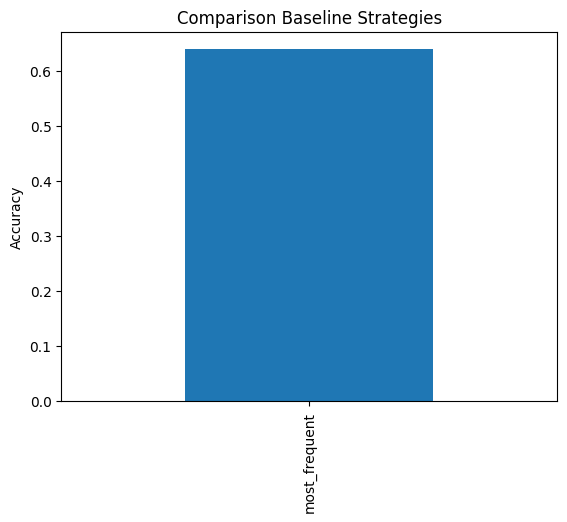

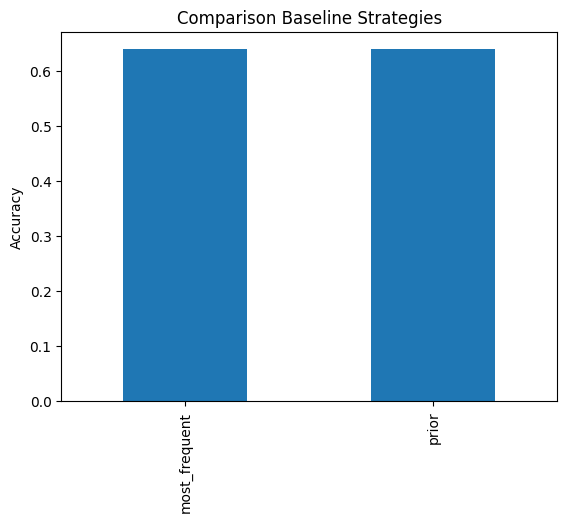

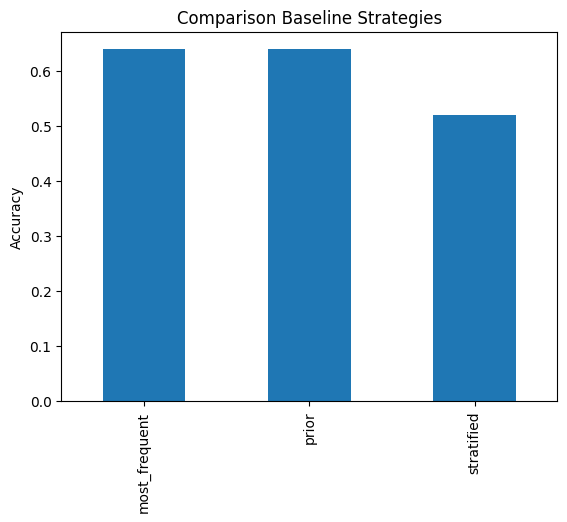

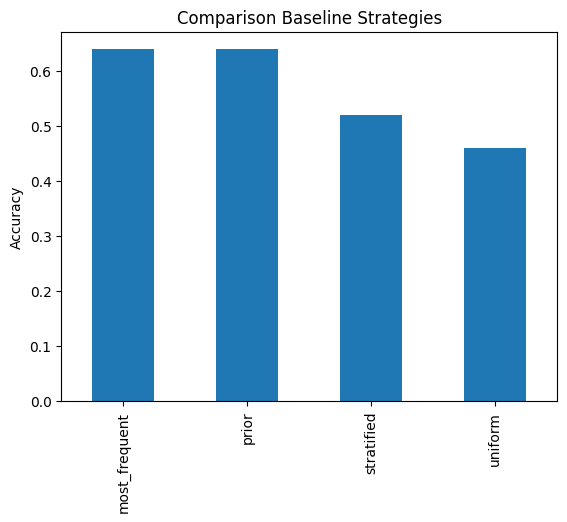

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

stratified = ["most_frequent" , "prior" , "stratified" , "uniform"]
results = {}

for strategy in stratified:
  model = DummyClassifier(strategy=strategy , random_state=42)
  model.fit(x_train,y_train)
  results[strategy] = accuracy_score(y_test,model.predict(x_test))


  pd.Series(results).plot(kind="bar")
  plt.ylabel("Accuracy")
  plt.title("Comparison Baseline Strategies")
  plt.show()

# Applying Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

tree = DecisionTreeClassifier(random_state=42)
tree.fit(x_train,y_train)

y_pred = tree.predict(x_test)
print("Test Accuracy:",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Test Accuracy: 0.88
              precision    recall  f1-score   support

           0       0.92      0.89      0.90        64
           1       0.82      0.86      0.84        36

    accuracy                           0.88       100
   macro avg       0.87      0.88      0.87       100
weighted avg       0.88      0.88      0.88       100



#Visualize Tree

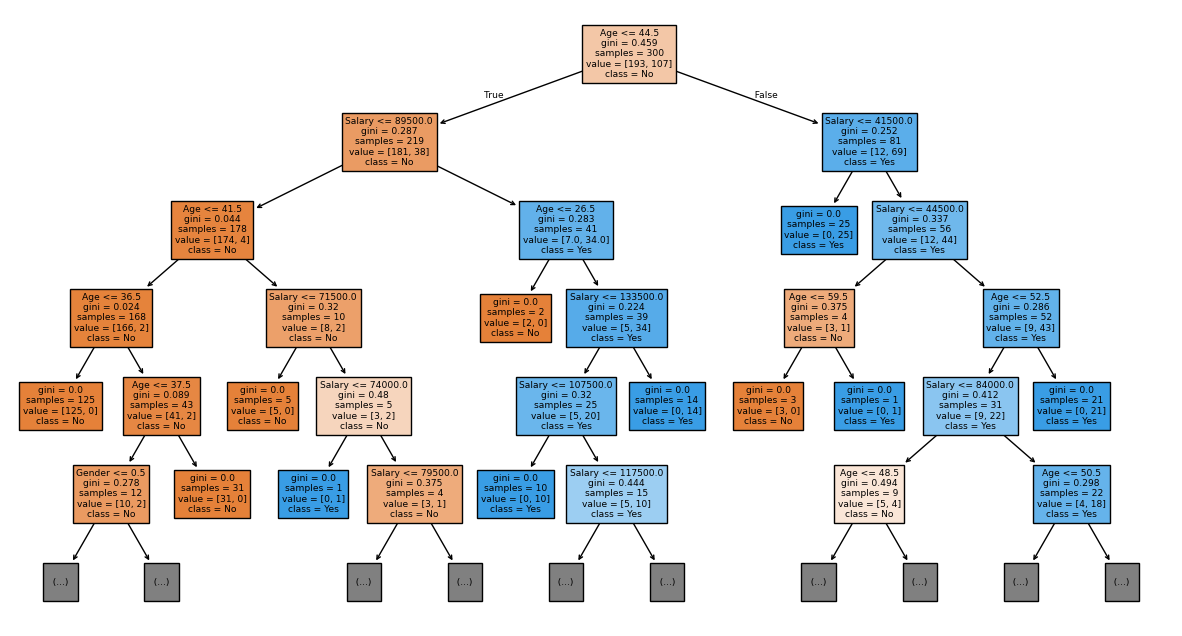

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))
plot_tree(tree,max_depth = 5,filled=True,feature_names=["Gender","Age","Salary"],
          class_names=["No","Yes"])
plt.show()

#Gini Accuracy and Entropy Accurcy


In [ ]:
tree_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
tree_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

tree_gini.fit(x_train, y_train)
tree_entropy.fit(x_train, y_train)

print("Gini Accuracy:", accuracy_score(y_test, tree_gini.predict(x_test)))
print("Entropy Accuracy:", accuracy_score(y_test, tree_entropy.predict(x_test)))

Gini Accuracy: 0.88
Entropy Accuracy: 0.89


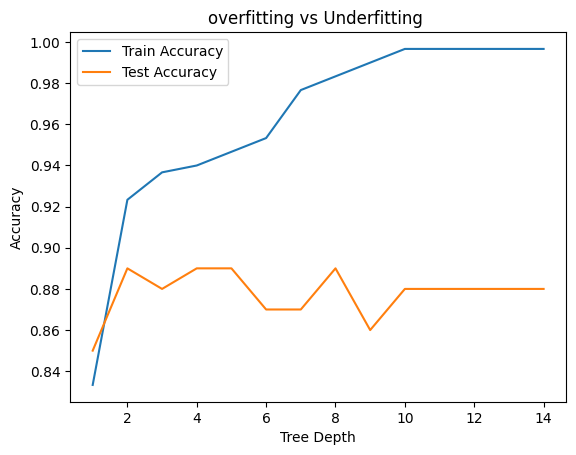

In [ ]:
depths = range(1,15)
train_acc, test_acc = [],[]

for d in depths:
  model = DecisionTreeClassifier(max_depth=d, random_state=42)
  model.fit(x_train, y_train)
  train_acc.append(model.score(x_train, y_train))
  test_acc.append(model.score(x_test,y_test))

plt.figure()
plt.plot(depths, train_acc, label='Train Accuracy')
plt.plot(depths, test_acc, label='Test Accuracy')
plt.xlabel("Tree Depth")
plt.ylabel('Accuracy')
plt.legend()
plt.title("overfitting vs Underfitting ")
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    "max_depth": [None, 3,5,7,10],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"]
}

grid = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5, scoring="accuracy")
grid.fit(x_train, y_train)
grid.best_params_

{'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}

#Scikit learn

#feature Importance

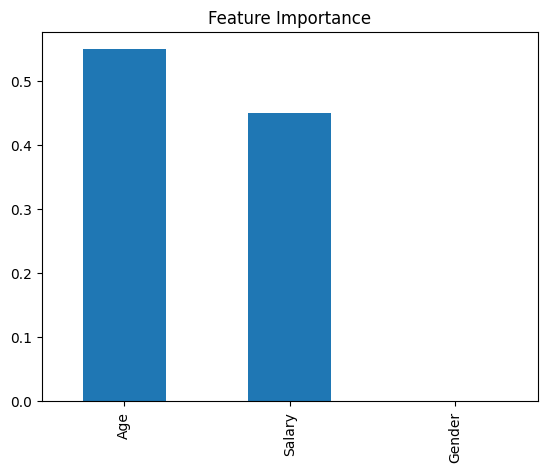

In [ ]:
best_tree = grid.best_estimator_
importances = best_tree.feature_importances_

feature = ["Gender", "Age", "Salary"]

pd.Series(importances, index=feature).sort_values(ascending=False).plot(kind="bar")
plt.title("Feature Importance")
plt.show()

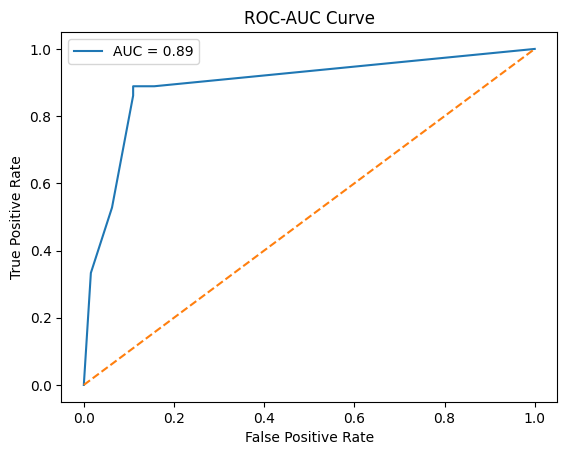

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_proba = best_tree.predict_proba(x_test)[:, 1]
fpr , tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")
plt.legend()
plt.show()